<a href="https://colab.research.google.com/github/heyaankit/pdm-industrial-app/blob/main/notebooks/1_pump_eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# necessary imports

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Loading dataset

df = pd.read_csv('drive/MyDrive/Datasets/PdM Dataset/Large_Industrial_Pump_Maintenance_Dataset.csv')

In [45]:
df.sample(50)

,Pump_ID,Temperature,Vibration,Pressure,Flow_Rate,RPM,Operational_Hours,Maintenance_Flag
9612,3,127.815114,3.680258,205.900373,0.605012,1796.493994,2216.858143,1
1802,1,98.730660,2.309137,293.197883,2.360447,2958.484788,4683.503726,1
9930,5,116.937190,3.367289,257.226884,19.058504,2991.243281,7843.003044,0
4917,3,139.090546,4.429135,141.940465,16.786377,2769.297116,4157.733977,1
5379,3,103.661081,1.205721,125.001534,13.049775,2589.177916,4060.523435,1
790,3,96.176037,0.898055,239.086104,5.729570,1986.262942,3971.756892,1
11721,2,126.388233,4.020558,270.086550,8.584519,1633.056245,3580.620213,1
15266,1,112.623306,2.620634,253.749222,11.634328,1267.296330,3248.658083,1
7316,5,60.029892,3.587467,221.874290,11.253124,2421.777444,8294.147443,0
8874,4,101.146331,0.720143,209.097936,10.601560,2388.016683,229.201861,1


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Pump_ID            20000 non-null  int64  
 1   Temperature        20000 non-null  float64
 2   Vibration          20000 non-null  float64
 3   Pressure           20000 non-null  float64
 4   Flow_Rate          20000 non-null  float64
 5   RPM                20000 non-null  float64
 6   Operational_Hours  20000 non-null  float64
 7   Maintenance_Flag   20000 non-null  int64  
dtypes: float64(6), int64(2)
memory usage: 1.2 MB


In [6]:
df.isnull().sum()

,0
Pump_ID,0
Temperature,0
Vibration,0
Pressure,0
Flow_Rate,0
RPM,0
Operational_Hours,0
Maintenance_Flag,0


In [8]:
df['Pump_ID'].unique()

array([2, 4, 3, 5, 1])

In [51]:
# Checking for any sentinel values present in the dataset which often represents missing values

sentinel_values = [0, -1, -999, -9999]

col_list = [
    'Temperature',
    'Vibration',
    'Pressure',
    'Flow_Rate',
    'RPM',
    'Operational_Hours',
    'Maintenance_Flag'
]


for col in col_list:
  if df[col].isin(sentinel_values).any():
    print(f"found in: {col}")
  else:
    print('all okay')

all okay
all okay
all okay
all okay
all okay
all okay
found in: Maintenance_Flag


In [52]:
df.describe()

,Pump_ID,Temperature,Vibration,Pressure,Flow_Rate,RPM,Operational_Hours,Maintenance_Flag
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.00000
mean,3.003550,100.371340,2.527856,200.381615,10.248111,2005.617191,5030.481037,0.49840
std,1.410368,28.851380,1.416466,57.823085,5.646254,576.506659,2867.804461,0.50001
min,1.000000,50.001091,0.100427,100.007052,0.500453,1000.041781,100.213880,0.00000
25%,2.000000,75.403208,1.300199,149.858536,5.354906,1506.073027,2531.552283,0.00000
50%,3.000000,100.752882,2.517715,200.513919,10.284599,2009.733748,5032.760791,0.00000
75%,4.000000,125.422558,3.755519,250.271651,15.149339,2503.339719,7504.463849,1.00000
max,5.000000,149.995262,4.999804,299.980845,19.999434,2999.915184,9998.768972,1.00000


In [53]:
# Skewness

for col in col_list:
  print(f"{col}: {df[col].skew():.4f}")

Temperature: -0.0184
Vibration: 0.0149
Pressure: -0.0126
Flow_Rate: -0.0072
RPM: -0.0037
Operational_Hours: 0.0099
Maintenance_Flag: 0.0064


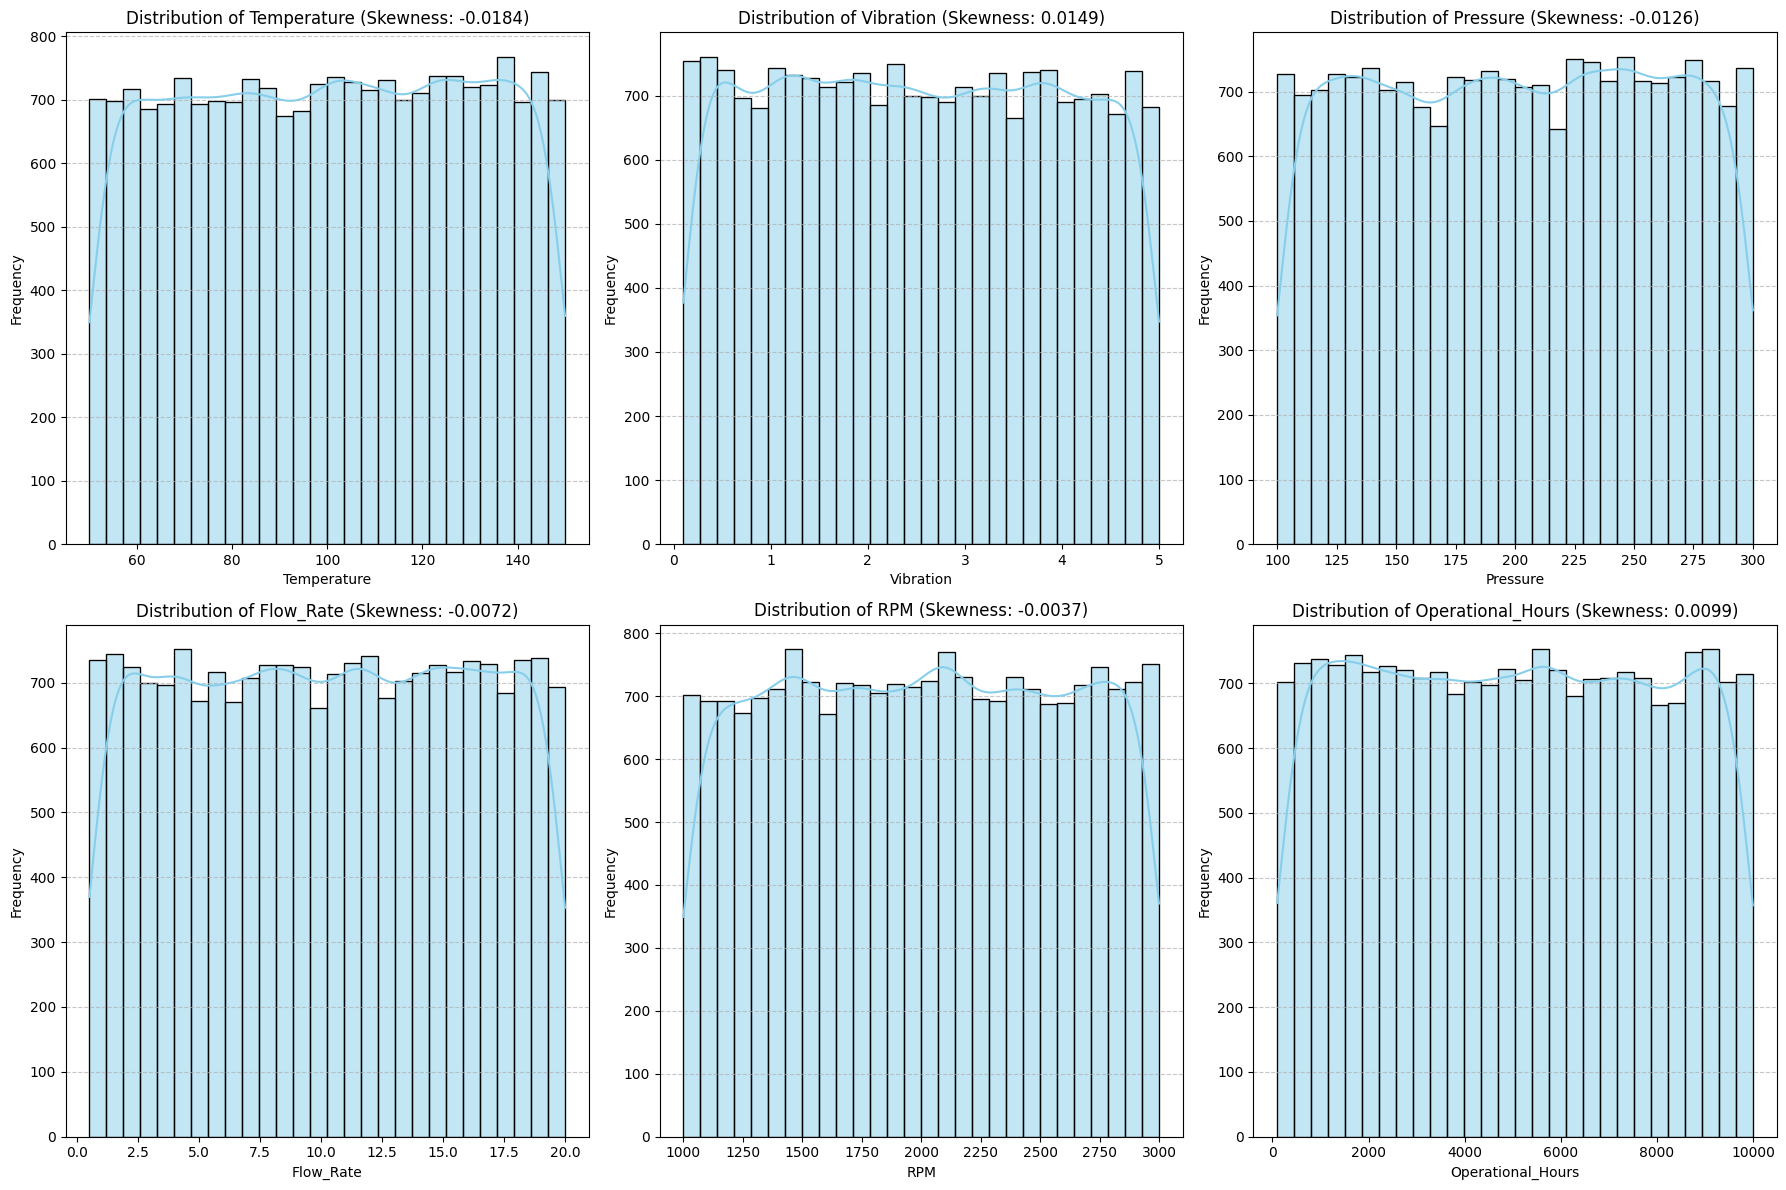

In [62]:
# Graphical representation of cols skewness

fig, axes = plt.subplots(2, 3, figsize=(18, 12)) # 2 rows, 3 columns
axes = axes.flatten() # Flatten the 2x3 array of axes for easy iteration

for i, col in enumerate(col_list):
  if col != 'Maintenance_Flag':
      skewness = df[col].skew()
      sns.histplot(df[col], kde=True, color='skyblue', ax=axes[i])
      axes[i].set_title(f'Distribution of {col} (Skewness: {skewness:.4f})')
      axes[i].set_xlabel(col)
      axes[i].set_ylabel('Frequency')
      axes[i].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout() # Adjust layout to prevent overlapping titles/labels
plt.show()

In [55]:
# Correlation matrix

corr = df[col_list].corr()
corr

,Temperature,Vibration,Pressure,Flow_Rate,RPM,Operational_Hours,Maintenance_Flag
Temperature,1.000000,-0.003828,0.010348,-0.007030,-0.002716,-0.005662,-0.013055
Vibration,-0.003828,1.000000,-0.000670,-0.010816,0.014048,0.006401,0.007575
Pressure,0.010348,-0.000670,1.000000,0.011846,0.013011,0.004281,-0.005164
Flow_Rate,-0.007030,-0.010816,0.011846,1.000000,0.001757,-0.004263,0.008674
RPM,-0.002716,0.014048,0.013011,0.001757,1.000000,0.008139,-0.008564
Operational_Hours,-0.005662,0.006401,0.004281,-0.004263,0.008139,1.000000,-0.003098
Maintenance_Flag,-0.013055,0.007575,-0.005164,0.008674,-0.008564,-0.003098,1.000000


In [57]:
# Correlation matrix with the target variable

corr_target = df[col_list].corr()['Maintenance_Flag'].sort_values(ascending=True)
corr_target

,Maintenance_Flag
Temperature,-0.013055
RPM,-0.008564
Pressure,-0.005164
Operational_Hours,-0.003098
Vibration,0.007575
Flow_Rate,0.008674
Maintenance_Flag,1.000000


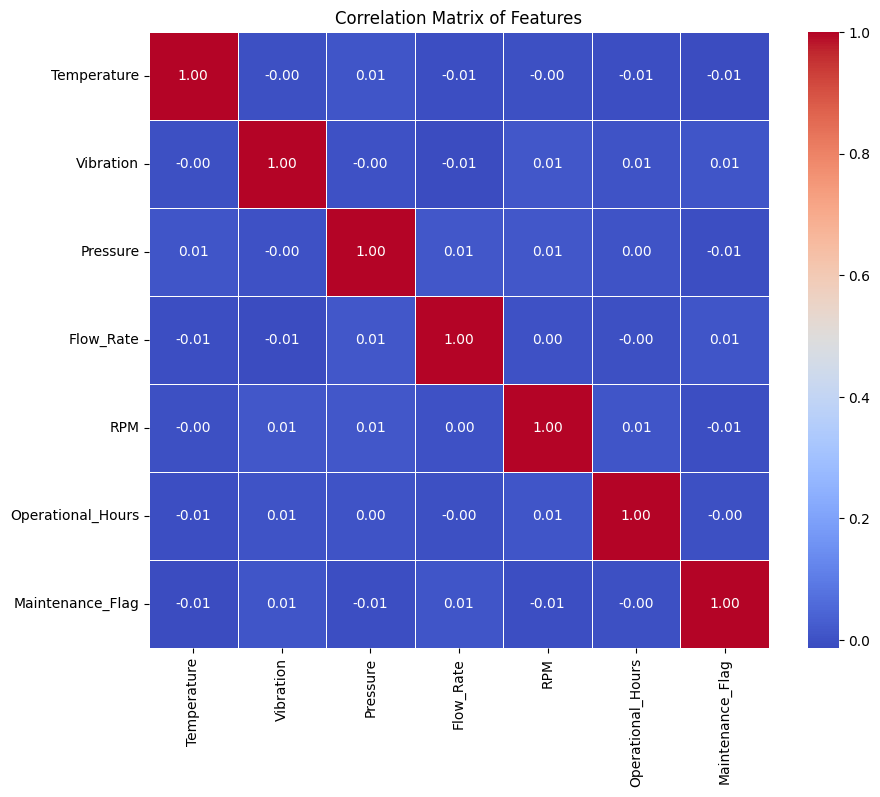

In [61]:
# Correlation matrix graph

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Features')
plt.show()